## Quick Data Exploration

This notebook shows the [data](https://www.kaggle.com/competitions/csiro-biomass/data)

Folder structure:
```
data/
    ├── test/
    ├── train/
    ├── sample_submission.csv
    ├── test.csv
    └── train.csv
```

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path
from PIL import Image

In [3]:
train_df = pd.read_csv('data/train.csv')
train_df.head(10)

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750
5,ID1012260530__Dry_Clover_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,Dry_Clover_g,0.0000
6,ID1012260530__Dry_Dead_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,Dry_Dead_g,0.0000
7,ID1012260530__Dry_Green_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,Dry_Green_g,7.6000
8,ID1012260530__Dry_Total_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,Dry_Total_g,7.6000
9,ID1012260530__GDM_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,GDM_g,7.6000


#### Number of images in train and test folders

In [4]:
dataset_root = Path("data")

splits = ["train", "test"]

for split in splits:
    d = dataset_root / split
    if not d.exists():
        print(f"{split}: MISSING -> {d}")
        continue
    count = sum(1 for p in d.iterdir() if p.is_file())
    print(f"{split} images: {count}")

train images: 357
test images: 1


Only 1 test image, we will use train images for training and validation and testing as 80-10-10 split.

#### Image sizes

In [5]:
for split in splits:
    d = dataset_root / split
    if not d.exists():
        print(f"{split}: MISSING -> {d}")
        continue
    exts = {".png", ".jpg", ".jpeg"}
    unique_sizes = set()
    for i, p in enumerate(sorted(d.iterdir())):
        if p.is_file() and p.suffix.lower() in exts:
            with Image.open(p) as img:
                unique_sizes.add((img.width, img.height))
        if i > 1:
            break # the image size is the same for all, checked before
    print(f"{split} image size: {unique_sizes}")

train image size: {(2000, 1000)}
test image size: {(2000, 1000)}


All images are 2000x1000 pixels -> possibly downsizing

#### Example image

In [7]:
img_list = os.listdir("data/train/")
print(img_list[:5])

['ID1011485656.jpg', 'ID1012260530.jpg', 'ID1025234388.jpg', 'ID1028611175.jpg', 'ID1035947949.jpg']


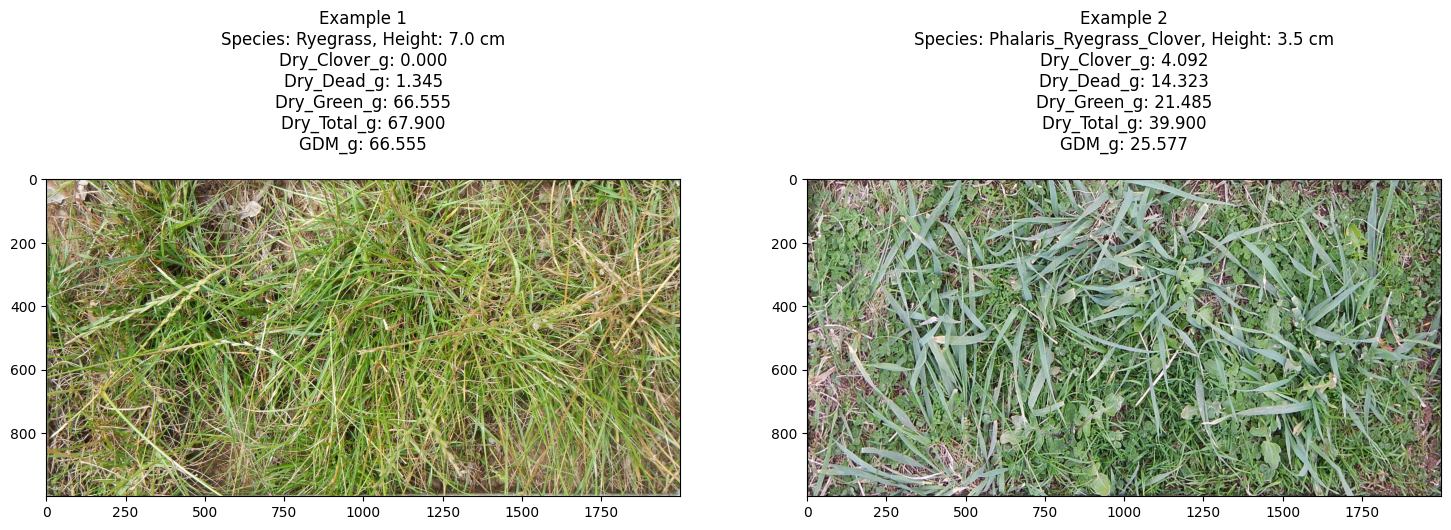

In [15]:
idx1 = 44
idx2 = 33
img_1 = cv2.imread(os.path.join("data", "train", img_list[idx1]))  
img_2 = cv2.imread(os.path.join("data", "train", img_list[idx2]))

df1 = train_df[train_df['image_path'] == "train/" +img_list[idx1]]
df2 = train_df[train_df['image_path'] == "train/" +img_list[idx2]]

data_str_1 = f"Species: {df1['Species'].values[0]}, Height: {df1['Height_Ave_cm'].values[0]:.1f} cm\n"
for i, row in df1.iterrows():
    data_str_1 += f"{row['target_name']}: {row['target']:.3f}\n"

data_str_2 = f"Species: {df2['Species'].values[0]}, Height: {df2['Height_Ave_cm'].values[0]:.1f} cm\n"
for i, row in df2.iterrows():
    data_str_2 += f"{row['target_name']}: {row['target']:.3f}\n"

# Convert BGR to RGB
img_1_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
img_2_rgb = cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(18, 38))
plt.subplot(1,2,1)
plt.imshow(img_1_rgb)
plt.title('Example 1\n' + data_str_1)
plt.subplot(1,2,2)
plt.imshow(img_2_rgb)
plt.title('Example 2\n' + data_str_2)
plt.show()